In [74]:
import pandas as pd
import pli_uso_pro as pup

In [75]:
# importação da base de dados contendo os parâmetros físico químicos monitorados

df_FQ = pd.read_excel("parametros_FQ_annex2.xlsx")
vari = df_FQ.columns[[4,5,6]].tolist()
df_FQ

,Day,Month,Hour,Product,Moisture (%),Acid Content (%),RS (%)
0,16,1,16:30:00,DR140,2.99,1.26,19.03
1,16,1,13:50:00,DR138,2.92,1.26,18.66
2,16,1,17:00:00,DR140,NaN,1.74,NaN
3,17,1,13:25:00,DR127,3.31,0.02,15.21
4,17,1,07:40:00,DR139,3.06,1.98,17.69
...,...,...,...,...,...,...,...
666,18,12,13:27:00,DR127,3.27,NaN,19.50
667,18,12,22:00:00,DR127,3.13,0.05,16.89
668,19,12,13:40:00,DR127,3.14,NaN,17.00
669,19,12,06:30:00,DR127,3.10,NaN,17.02


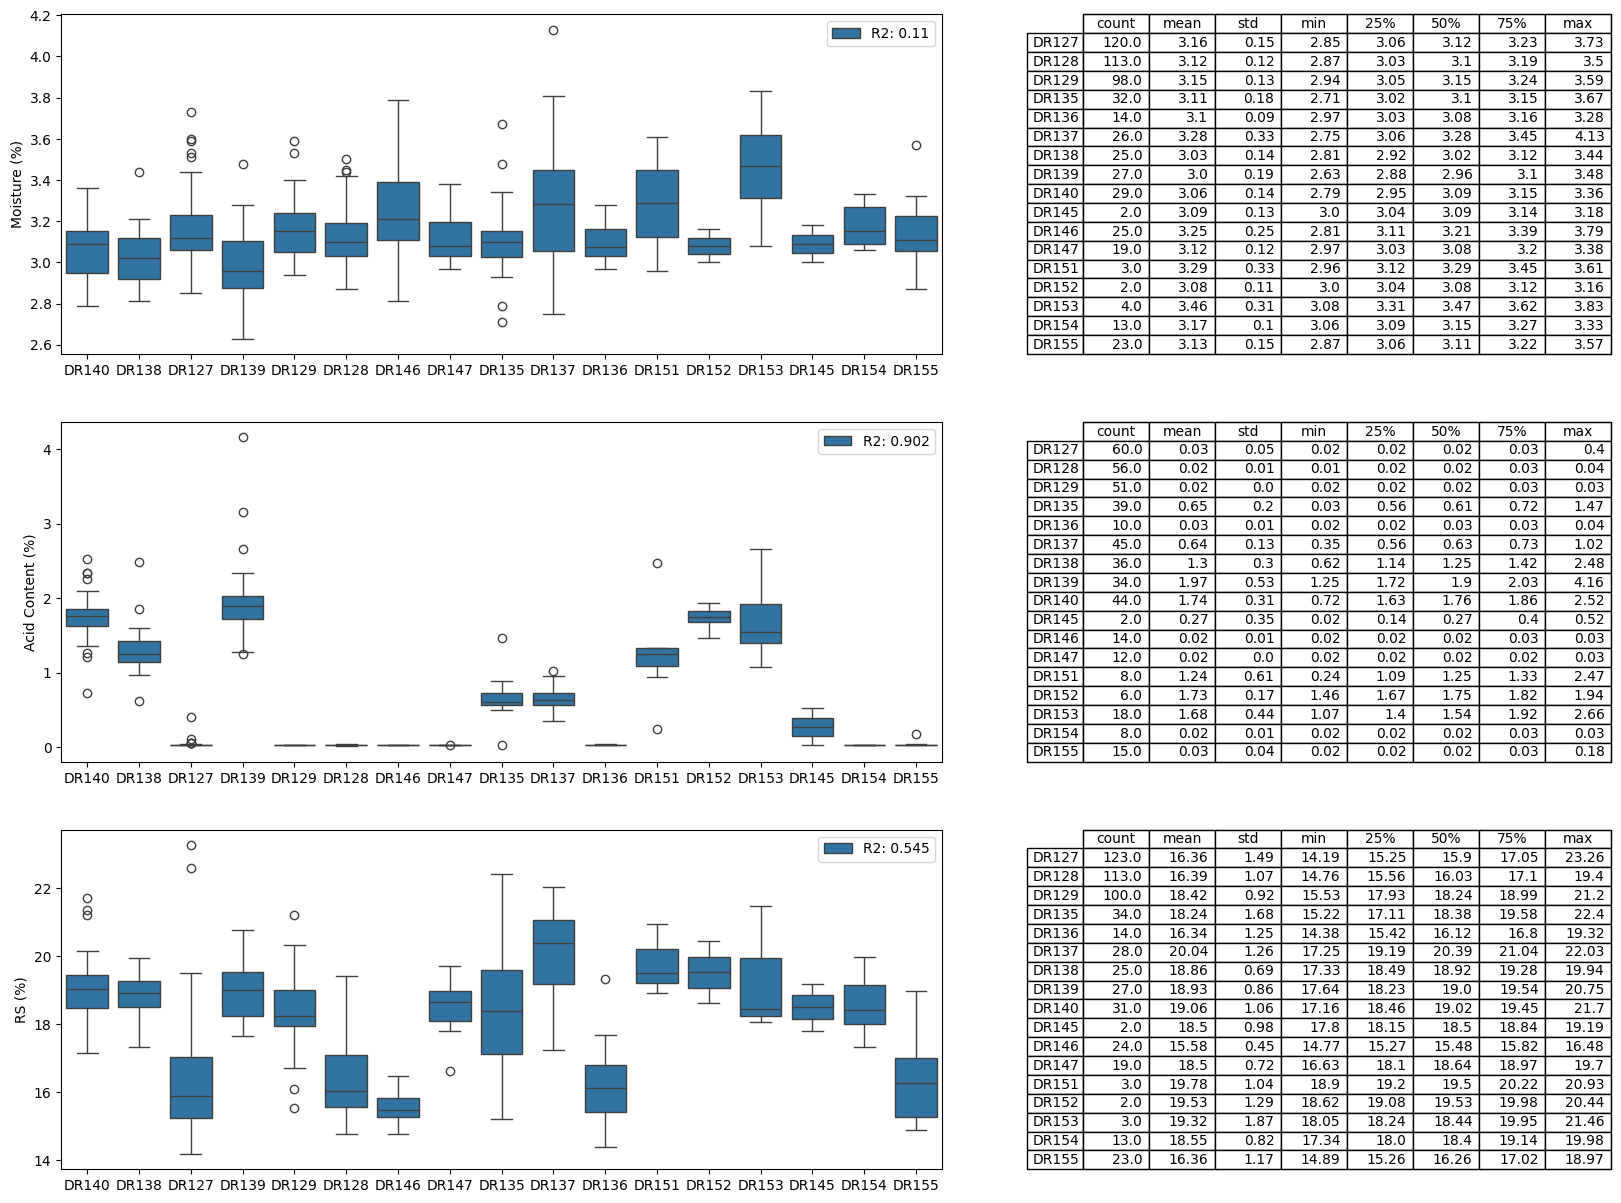

In [23]:
# utilização da rotina "resumo" para obter um resumo descritivo dos parâmetros monitorados, segmentados por sabor
# "Moisture" e "RS" não deveriam apresentar um valor de R2 significante (>0,5), pois todos os sabores devem ter uma medida padronizada de "Moisture" e "RS"
# A quantidade de ácido deve ter correlação relevante com os sabores, sendo que cada sabor tem uma dosagem de ácido própria
# A esquerda: boxplot dos parâmetros monitorados segmentados por sabor
# A direita: as medidas descritivas para cada sabor

teste1 = pup.resumo(df_FQ, "Product", vari, (20,15))

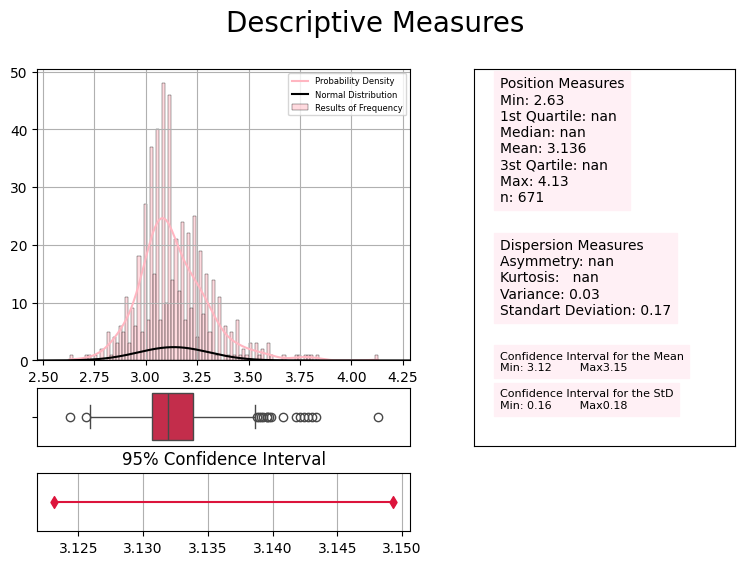

In [31]:
# medidas descritivas para a umidade

moisture = df_FQ["Moisture (%)"]
pup.descritiva(moisture, 100)

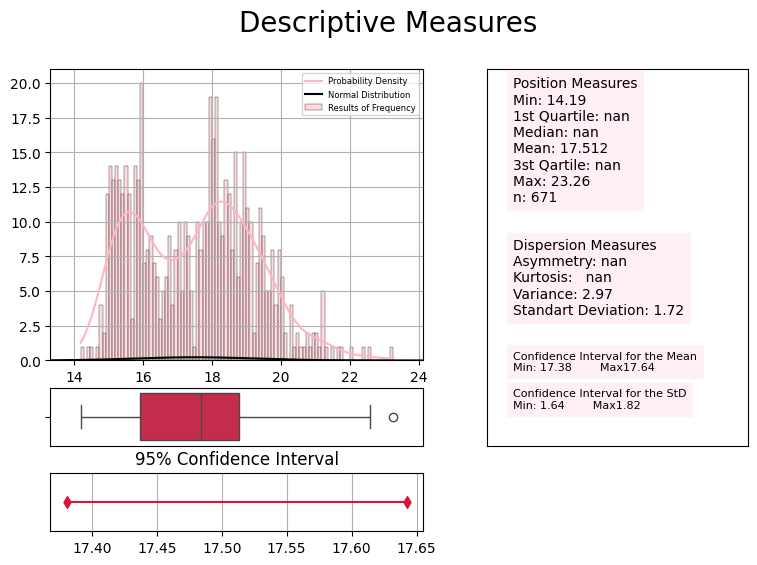

In [33]:
# medidas descritivas para o açúcar redutor
red_su = df_FQ["RS (%)"]
pup.descritiva(red_su, 100)

In [27]:
# Importação dos parâmetros de produção obtidos durante o monitoramento

df_prod = pd.read_excel("parametros_prod_Annex1.xlsx")
vari1 = df_prod.columns[[3,4,5]]
df_prod

,turno,Date,Hour,Vacuum (mmHg),Temperature (ºC),Speed (kg/h),Product
0,1,2023-08-07,11:10:00,295,132,703,DR127
1,2,2023-12-05,20:45:00,297,134,691,DR127
2,3,2023-12-09,00:37:00,299,137,722,DR138
3,2,2023-09-06,14:04:00,241,131,712,DR128
4,2,2023-08-23,10:20:00,289,135,708,DR139
...,...,...,...,...,...,...,...
309,3,2023-11-21,00:10:00,305,132,727,DR135
310,2,2023-09-04,20:39:00,306,132,727,DR128
311,1,2023-09-05,07:47:00,307,132,703,DR128
312,1,2023-12-07,11:00:00,295,134,681,DR151


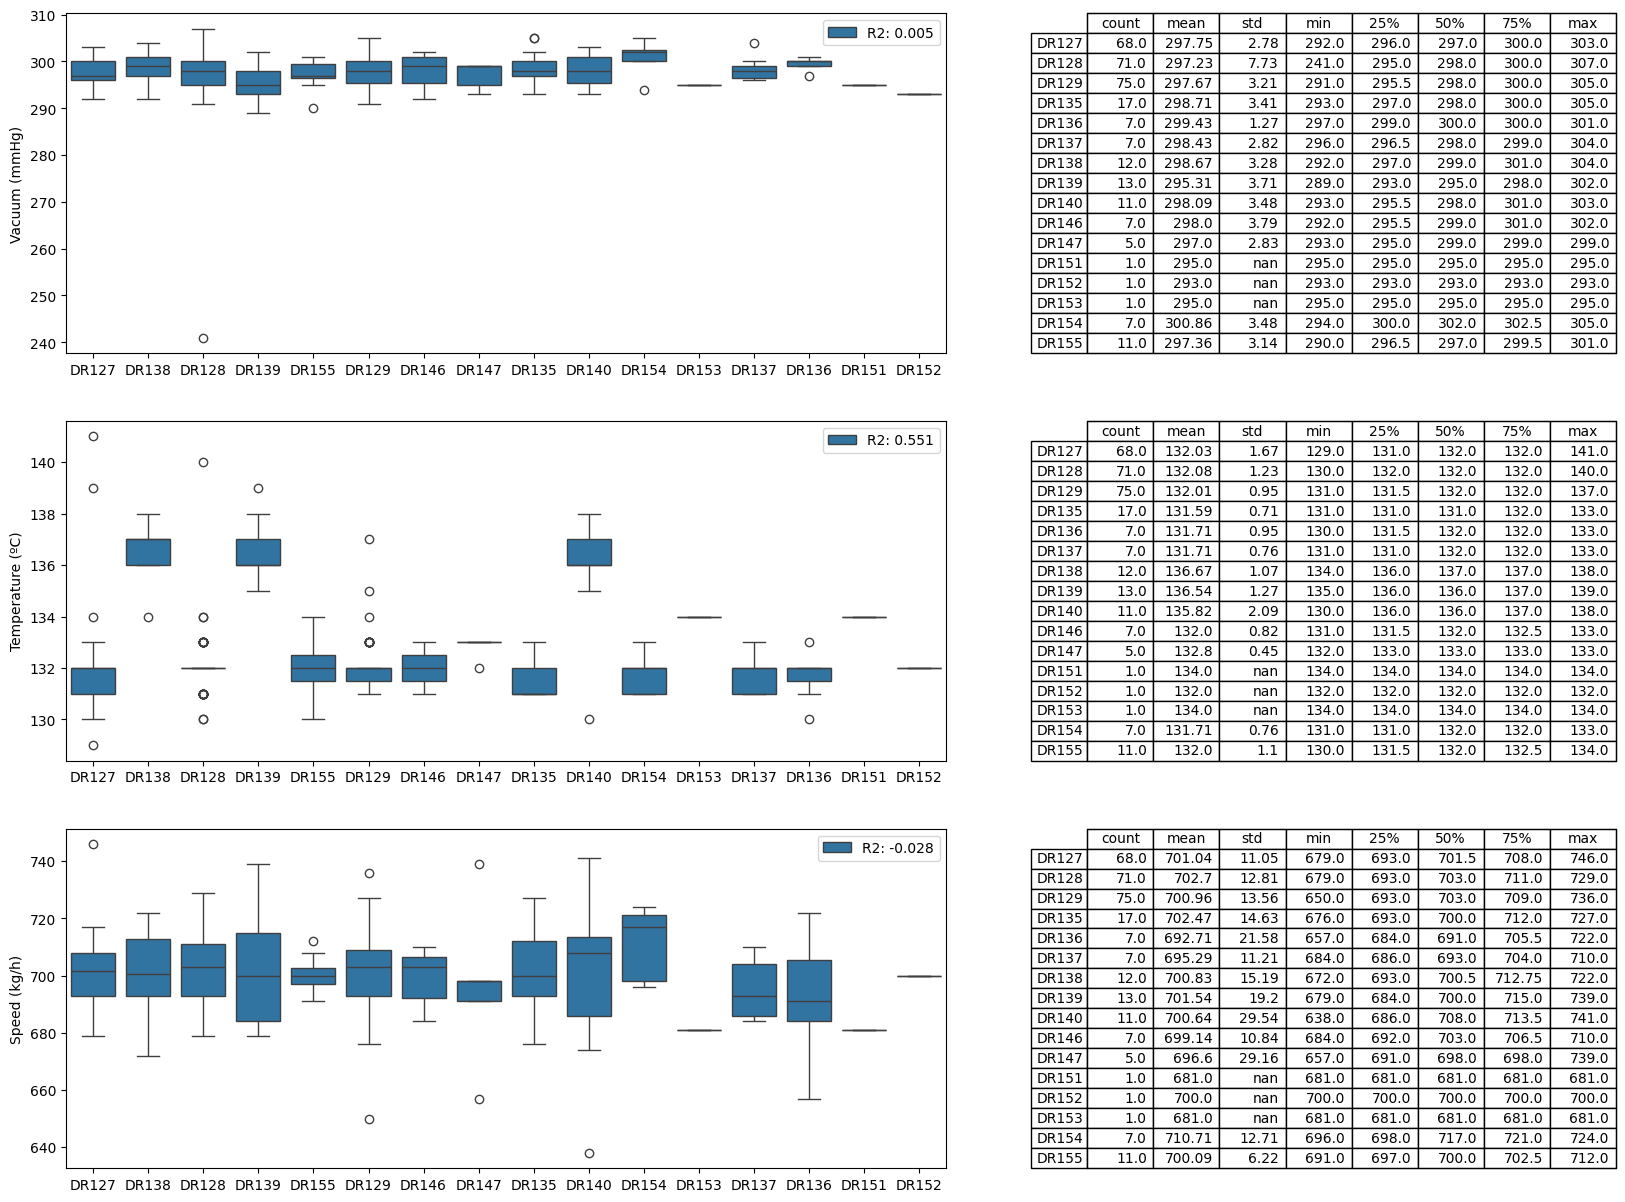

In [29]:
# A esquerda: boxplot dos parâmetros monitorados segmentados por sabor
# A direita: as medidas descritivas para cada sabor

pup.resumo(df_prod, "Product", vari1, (20,15))

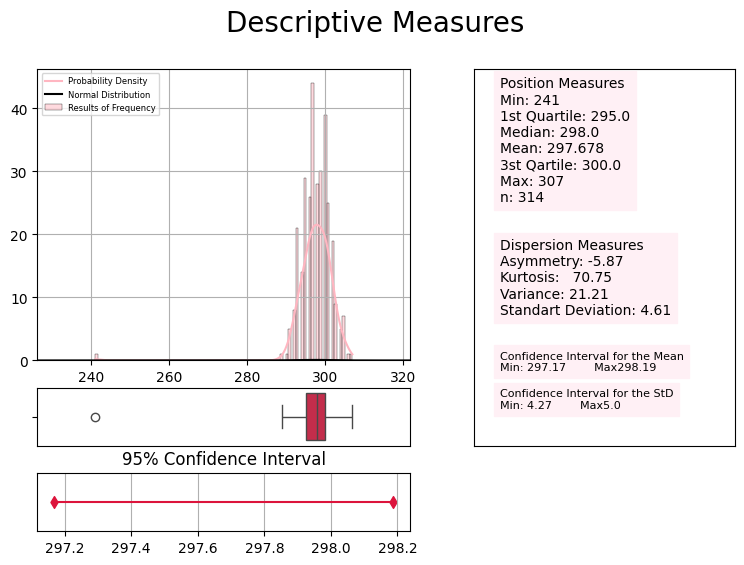

In [34]:
# medidas descritivas para o vácuo de cozimento

vacuum = df_prod["Vacuum (mmHg)"]
pup.descritiva(vacuum, 100)

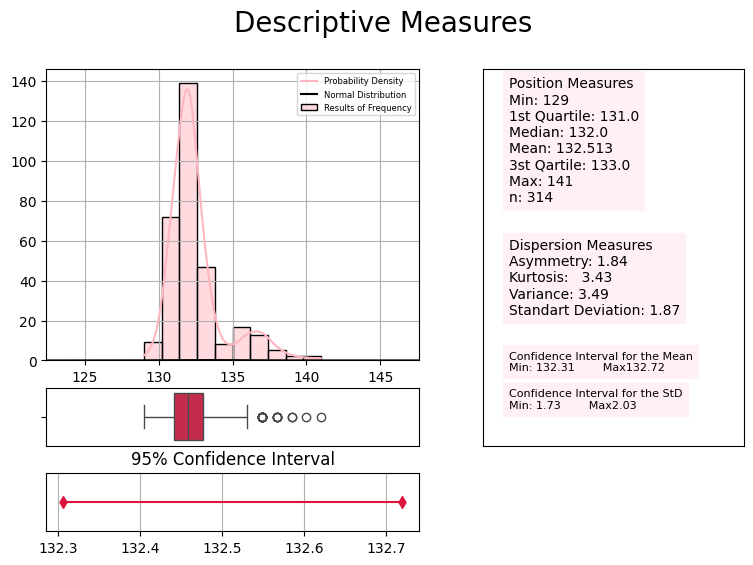

In [38]:
# medidas descritivas para a temperatura de cozimento

temp = df_prod["Temperature (ºC)"]
pup.descritiva(temp, 10)

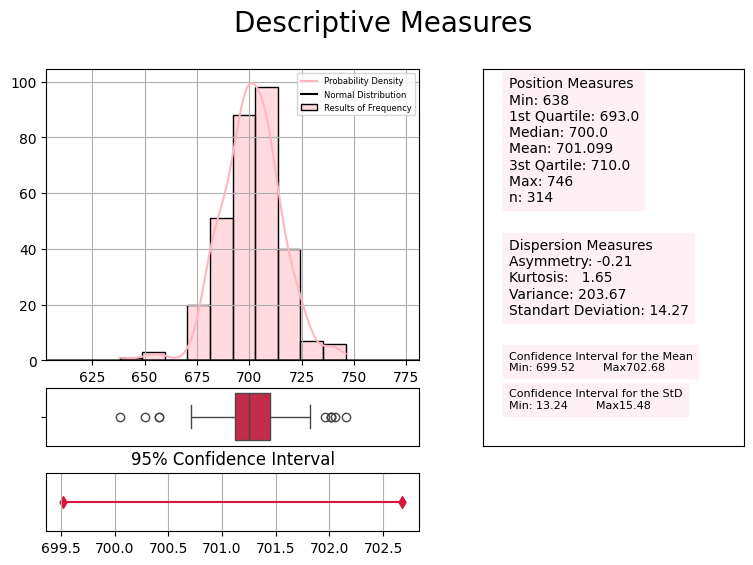

In [40]:
# medidas descritivas para a velocidade de produção

speed = df_prod["Speed (kg/h)"]
pup.descritiva(speed, 10)

In [52]:
# importação da base de dados usada para investigação de correlação

teste = pd.read_excel("corr_annex3.xlsx")
teste.columns = teste.iloc[0]
teste.drop(0, axis = 0, inplace = True)
analise = teste.iloc[:,[2,3,4,8,9,10]]

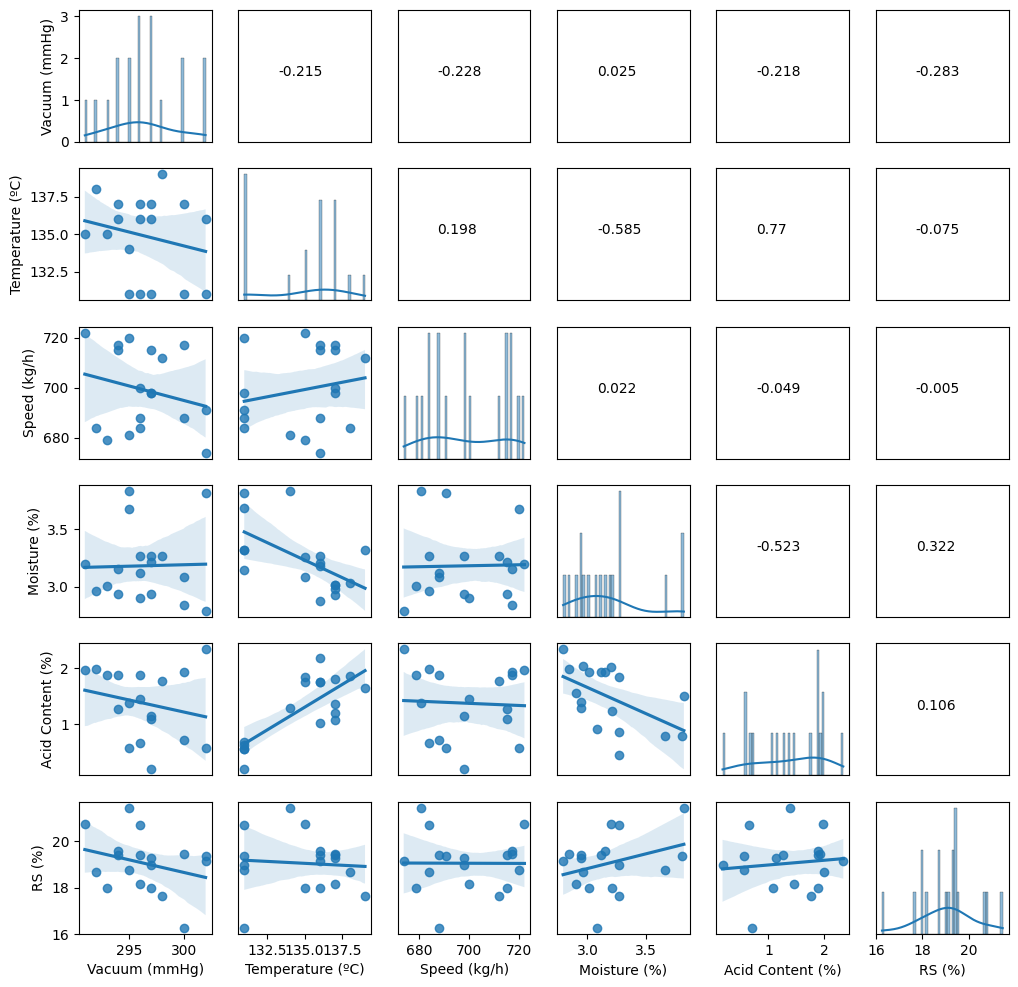

In [72]:
# plot da matriz de correlação para as amostras com teor de ácido significante ">0.1"

analise_ac = analise[analise["Acid Content (%)"] > 0.1]
analise_ac = analise_ac.apply(pd.to_numeric, errors = "coerce")
analise_ac.dropna()
pup.matriz_corr(analise_ac, analise_ac.columns.tolist(), (12,12))

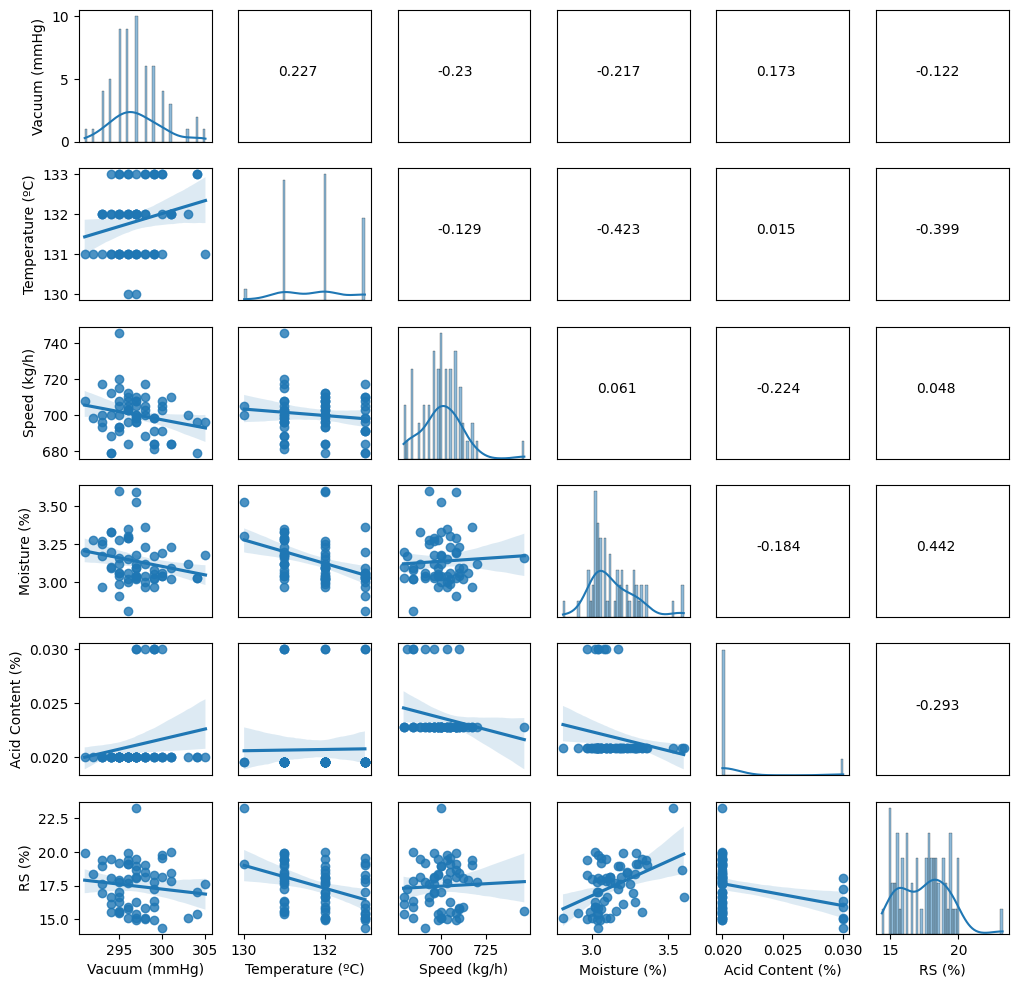

In [73]:
# plot da matriz de correlação para as amostras com teor de ácido significante "<0.1"

analise_sa = analise[analise["Acid Content (%)"] < 0.1]
analise_sa = analise_sa.apply(pd.to_numeric, errors = "coerce")
analise_sa.dropna()
pup.matriz_corr(analise_sa, analise_ac.columns.tolist(), (12,12))